<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/eval2-TabordaLopez/Evaluacion2/TabordaLopez/solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Entrega evaluacion 2  
**Estudiante**: Alejandro Taborda Lopez  
**Cedula**: 100090**1151**  
**Correo**: altabordal@unal.edu.co


##Configuracion del entorno

In [3]:
!sudo apt-get update
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super

import numpy as np
import jax
import jax.numpy as jnp
from jax import grad, jit
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid                          # ← bug 1: sintaxis mezclada
    "grid.color"    : "gray",       # todo debe ir como claves del dict
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).
dvipng is already the newest version (1.15-

## Importacion de los datos  


Variables en el archivo: ['X', 'y', 't', 'meta']
Dimensiones de X: (45, 256)
Es decir, tiene 45 muestras (o experimentos) y cada una consiste en un arreglo de 256 valores.
Dimensiones de y: (45,)
Este vector y contiene las etiquetas o valores objetivo correspondientes a cada una de las 45 muestras.
Dimensiones de t: (256,)
Este vector t contiene los tiempos asociados a cada una de las 256 muestras.
Metadatos: ['1151' '24b0875c1b5289f6' '2026-07-12T19:19:08']


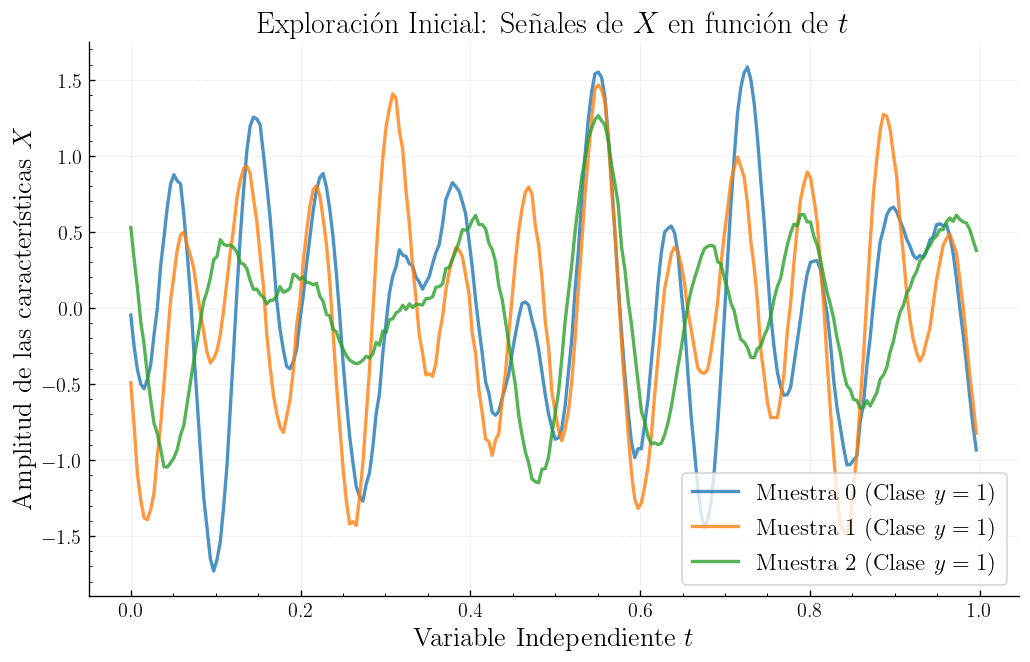

In [14]:
#Importacion usando la url del repositorio
url = "https://raw.githubusercontent.com/manubastidas/programacionCientifica/eval2-TabordaLopez/Evaluacion2/TabordaLopez/datos_1151.npz"
!wget -q {url} -O datos_1151.npz

# Cargar datos
datos = np.load("datos_1151.npz")

#Exploracion de los datos:
print("Variables en el archivo:", datos.files)
X = datos['X']
y = datos['y']
t = datos['t']
meta = datos['meta']
print(f"Dimensiones de X: {X.shape}")
print("Es decir, tiene 45 muestras (o experimentos) y cada una consiste en un arreglo de 256 valores.")
print(f"Dimensiones de y: {y.shape}")
print("Este vector y contiene las etiquetas o valores objetivo correspondientes a cada una de las 45 muestras.")
print(f"Dimensiones de t: {t.shape}")
print("Este vector t contiene los tiempos asociados a cada una de las 256 muestras.")
print(f"Metadatos: {meta}")
plt.figure(figsize=(10, 6))

# Como tenemos 45 muestras, graficar todas juntas sería un desorden visual.
# Vamos a graficar solo las primeras 3 muestras para explorar los datos.
for i in range(3):
    plt.plot(t, X[i, :], label=f'Muestra {i} (Clase $y={y[i]}$)', alpha=0.8, linewidth=2)

plt.title('Exploración Inicial: Señales de $X$ en función de $t$')
plt.xlabel('Variable Independiente $t$')
plt.ylabel('Amplitud de las características $X$')
plt.legend()
plt.grid(True)
plt.show()